## Buyer Segmentation


In [26]:
import pandas as pd 
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('clients.csv')
data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [3]:
data.tail()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
1995,C1996,Individual,Samantha,Brooks,6/20/1992,F,USA,Nevada,Home,1,Yes,Website
1996,C1997,Individual,Matthew,Cox,9/27/1942,M,USA,Arizona,Home,4,Yes,Website
1997,C1998,Individual,Mark,Patterson,9/13/1963,M,USA,Virginia,Home,5,Yes,Website
1998,C1999,Individual,Lawrence,Montgomery,6/15/1944,M,USA,Ohio,Home,4,Yes,Client
1999,C2000,Individual,Amanda,James,3/24/1996,F,USA,Georgia,Home,1,Yes,Agency


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
for col in ['client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']:
    print(col,data[col].unique())

client_type ['Individual' 'Company']
gender ['F' 'M']
country ['USA' 'Canada' 'Germany' 'Belgium' 'Mexico' 'Russia' 'UK' 'Denmark'
 'France' 'Australia']
region ['California' 'Quebec' 'Oregon' 'Arizona' 'Berlin' 'Nevada' 'Colorado'
 'Brussels' 'Mexico City' 'Krasnodar Krai' 'Utah' 'Northern Ireland'
 'Capital Region' 'Virginia' 'Wyoming' 'Kansas' 'Saint Petersburg'
 'Scotland' 'Novosibirsk' 'Ohio' 'Washington' 'England' 'Texas'
 'North Rhine-Westphalia' 'Florida' 'Ile-de-France' 'British Columbia'
 'Puebla' 'Provence' 'Hamburg' 'Ontario' 'Central Denmark' 'New York'
 'Manitoba' 'Nuevo Leon' 'Normandy' 'Flanders' 'Georgia' 'Zealand'
 'New South Wales' 'Tatarstan' 'Wales' 'Alberta' 'Baja California' 'Hesse'
 'Wallonia' 'Victoria' 'Jalisco' 'Brittany' 'Bavaria' 'North Denmark'
 'South Australia' 'Occitanie' 'Southern Denmark' 'Queensland'
 'Moscow Oblast' 'Western Australia']
acquisition_purpose ['Home' 'Investment']
loan_applied ['Yes' 'No']
referral_channel ['Website' 'Agency' 'Client']

In [7]:
data = data.drop(["client_id","first_name","last_name"],axis=1)

In [8]:
data.duplicated().sum()

np.int64(1)

In [9]:
data[data.duplicated(keep=False)]

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
77,Individual,4/23/1948,F,USA,California,Home,5,No,Website
93,Individual,4/23/1948,F,USA,California,Home,5,No,Website


In [10]:
data = data.drop_duplicates()

In [11]:
data['date_of_birth'] = data['date_of_birth'].str.replace('/','-')
data

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,Individual,05-11-1968,F,USA,California,Home,4,Yes,Website
1,Individual,11-26-1962,M,USA,California,Home,1,No,Website
2,Individual,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,Individual,11-25-1959,M,USA,California,Home,5,No,Website
4,Company,2-28-1976,M,USA,California,Investment,5,No,Website
...,...,...,...,...,...,...,...,...,...
1995,Individual,6-20-1992,F,USA,Nevada,Home,1,Yes,Website
1996,Individual,9-27-1942,M,USA,Arizona,Home,4,Yes,Website
1997,Individual,9-13-1963,M,USA,Virginia,Home,5,Yes,Website
1998,Individual,6-15-1944,M,USA,Ohio,Home,4,Yes,Client


In [12]:
data['date_of_birth'] = pd.to_datetime(data['date_of_birth'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1999 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   client_type          1999 non-null   object        
 1   date_of_birth        1999 non-null   datetime64[ns]
 2   gender               1999 non-null   object        
 3   country              1999 non-null   object        
 4   region               1999 non-null   object        
 5   acquisition_purpose  1999 non-null   object        
 6   satisfaction_score   1999 non-null   int64         
 7   loan_applied         1999 non-null   object        
 8   referral_channel     1999 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 156.2+ KB


In [13]:
data['birth_year'] = data['date_of_birth'].dt.year
data['birth_month'] = data['date_of_birth'].dt.month
data

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,birth_year,birth_month
0,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,1968,5
1,Individual,1962-11-26,M,USA,California,Home,1,No,Website,1962,11
2,Individual,1959-04-07,M,USA,California,Home,4,Yes,Agency,1959,4
3,Individual,1959-11-25,M,USA,California,Home,5,No,Website,1959,11
4,Company,1976-02-28,M,USA,California,Investment,5,No,Website,1976,2
...,...,...,...,...,...,...,...,...,...,...,...
1995,Individual,1992-06-20,F,USA,Nevada,Home,1,Yes,Website,1992,6
1996,Individual,1942-09-27,M,USA,Arizona,Home,4,Yes,Website,1942,9
1997,Individual,1963-09-13,M,USA,Virginia,Home,5,Yes,Website,1963,9
1998,Individual,1944-06-15,M,USA,Ohio,Home,4,Yes,Client,1944,6


In [14]:
data['birth_year'].unique()

array([1968, 1962, 1959, 1976, 1957, 1947, 1969, 1975, 1966, 1956, 1980,
       1941, 1939, 1977, 1967, 1938, 1958, 1963, 1937, 1952, 1965, 1973,
       1974, 1931, 1964, 1970, 1971, 1940, 1954, 1933, 1960, 1972, 1942,
       1985, 1953, 1948, 1949, 1943, 1981, 1979, 1936, 1982, 1951, 1978,
       1955, 1950, 1946, 1932, 1986, 1983, 1984, 1990, 1991, 1992, 1993,
       1988, 1994, 1945, 1944, 1996, 1999, 1987, 1997, 1998, 1961, 2000,
       1995, 1989], dtype=int32)

In [15]:
data['Age'] = (datetime.today() - data['date_of_birth']).dt.days // 365
data

,client_type,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,birth_year,birth_month,Age
0,Individual,1968-05-11,F,USA,California,Home,4,Yes,Website,1968,5,57
1,Individual,1962-11-26,M,USA,California,Home,1,No,Website,1962,11,63
2,Individual,1959-04-07,M,USA,California,Home,4,Yes,Agency,1959,4,66
3,Individual,1959-11-25,M,USA,California,Home,5,No,Website,1959,11,66
4,Company,1976-02-28,M,USA,California,Investment,5,No,Website,1976,2,50
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Individual,1992-06-20,F,USA,Nevada,Home,1,Yes,Website,1992,6,33
1996,Individual,1942-09-27,M,USA,Arizona,Home,4,Yes,Website,1942,9,83
1997,Individual,1963-09-13,M,USA,Virginia,Home,5,Yes,Website,1963,9,62
1998,Individual,1944-06-15,M,USA,Ohio,Home,4,Yes,Client,1944,6,81


In [16]:
data['Age'].unique()

array([57, 63, 66, 50, 69, 78, 56, 59, 45, 84, 86, 49, 68, 58, 87, 67, 62,
       89, 73, 48, 60, 52, 64, 51, 95, 61, 55, 54, 85, 72, 92, 65, 53, 83,
       40, 70, 77, 82, 44, 46, 76, 43, 75, 79, 47, 93, 39, 71, 74, 42, 35,
       34, 33, 32, 37, 80, 36, 81, 29, 26, 41, 38, 28, 27, 31, 25, 30])

In [17]:
print(data['Age'].max())
print(data['Age'].min())

95
25


In [18]:
data = data.drop(['date_of_birth'],axis=1)
data

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,birth_year,birth_month,Age
0,Individual,F,USA,California,Home,4,Yes,Website,1968,5,57
1,Individual,M,USA,California,Home,1,No,Website,1962,11,63
2,Individual,M,USA,California,Home,4,Yes,Agency,1959,4,66
3,Individual,M,USA,California,Home,5,No,Website,1959,11,66
4,Company,M,USA,California,Investment,5,No,Website,1976,2,50
...,...,...,...,...,...,...,...,...,...,...,...
1995,Individual,F,USA,Nevada,Home,1,Yes,Website,1992,6,33
1996,Individual,M,USA,Arizona,Home,4,Yes,Website,1942,9,83
1997,Individual,M,USA,Virginia,Home,5,Yes,Website,1963,9,62
1998,Individual,M,USA,Ohio,Home,4,Yes,Client,1944,6,81


In [19]:
X = data[['country','region','client_type','gender','acquisition_purpose','loan_applied','referral_channel','satisfaction_score','birth_year','birth_month','Age']]

In [20]:
X.head()

,country,region,client_type,gender,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,birth_year,birth_month,Age
0,USA,California,Individual,F,Home,Yes,Website,4,1968,5,57
1,USA,California,Individual,M,Home,No,Website,1,1962,11,63
2,USA,California,Individual,M,Home,Yes,Agency,4,1959,4,66
3,USA,California,Individual,M,Home,No,Website,5,1959,11,66
4,USA,California,Company,M,Investment,No,Website,5,1976,2,50


In [21]:

onehotcol = ['country','region','client_type','gender','acquisition_purpose','loan_applied','referral_channel']
scalercol = ['satisfaction_score','birth_year','birth_month','Age']

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

cm = ColumnTransformer(
    transformers =
    [
        ('oe',OneHotEncoder(handle_unknown='ignore', sparse_output = False),onehotcol),
        ('sc',StandardScaler(),scalercol)
    ], remainder='drop'
)

In [23]:
X_processed = cm.fit_transform(X)

In [24]:
pd.DataFrame(X_processed)

,0,1,2,3,4,5,6,7,8,9,...,72,73,74,75,76,77,78,79,80,81
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.687949,-0.110283,-0.449023,0.095735
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,-1.435382,-0.456368,1.298974,0.441593
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.687949,-0.629410,-0.740355,0.614521
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.395726,-0.629410,1.298974,0.614521
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.395726,0.351163,-1.323021,-0.307765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,-1.435382,1.274056,-0.157690,-1.287695
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.687949,-1.609983,0.716308,1.594451
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.395726,-0.398687,0.716308,0.383950
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.687949,-1.494622,-0.157690,1.479165


In [ ]:
# Elbow Method to find K.

sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(X_processed)
    sse.append(km.inertia_)

c:\Users\Adarsh tayade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Adarsh tayade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Adarsh tayade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Adarsh tayade\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

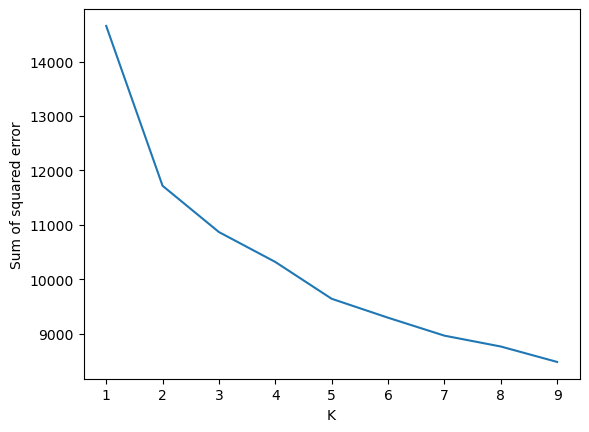

In [ ]:
# Elbow curve .

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)